# Python project

##### Dataset:

I used Healthcare Insurance data from Kaggle. The dataset includes demographic infor-
mation such as age, sex, family size, and smoking status.

In [ ]:
# Import/install required packages
import sys
print(sys.version)

# Install dependencies as needed: read data from online
%pip install "kagglehub[pandas-datasets]"

#  data manipulation
%pip install pandas numpy scikit-learn openpyxl
%pip install  matplotlib
%pip install  seaborn


In [23]:
# load modules
import pandas as pd # Working for data frame tables
import numpy as np # Using for maths(numbers)
import kagglehub
import matplotlib.pyplot as plt # Visualizing data in different format like Charts,....
%matplotlib inline 
import seaborn as sns
from kagglehub import KaggleDatasetAdapter
from sklearn.linear_model import LinearRegression

In [24]:
# read online datta from Kaggle
file_path = "insurance.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "willianoliveiragibin/healthcare-insurance",
    file_path,
)
#print("First 5 records",df.head())


C:\Users\felem\AppData\Local\Temp/ipykernel_25144/2528098559.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


# To check structured summary of the DataFrame

In [ ]:
#To check the structured summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [590]:
# to know the columns name
df.columns 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_group'],
      dtype='object')

In [ ]:
#Check for missing values - no missing values in the dataset
df.info() # data info
print(df.isnull().sum())

In [592]:
# Summary statistics of the dataset
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [593]:
# Count group by sex
print(df.groupby("sex").size())

sex
female    662
male      676
dtype: int64


The age distibution ranged from 15 to 64 with the mean age of 39 and skweed to the youngest population to the left

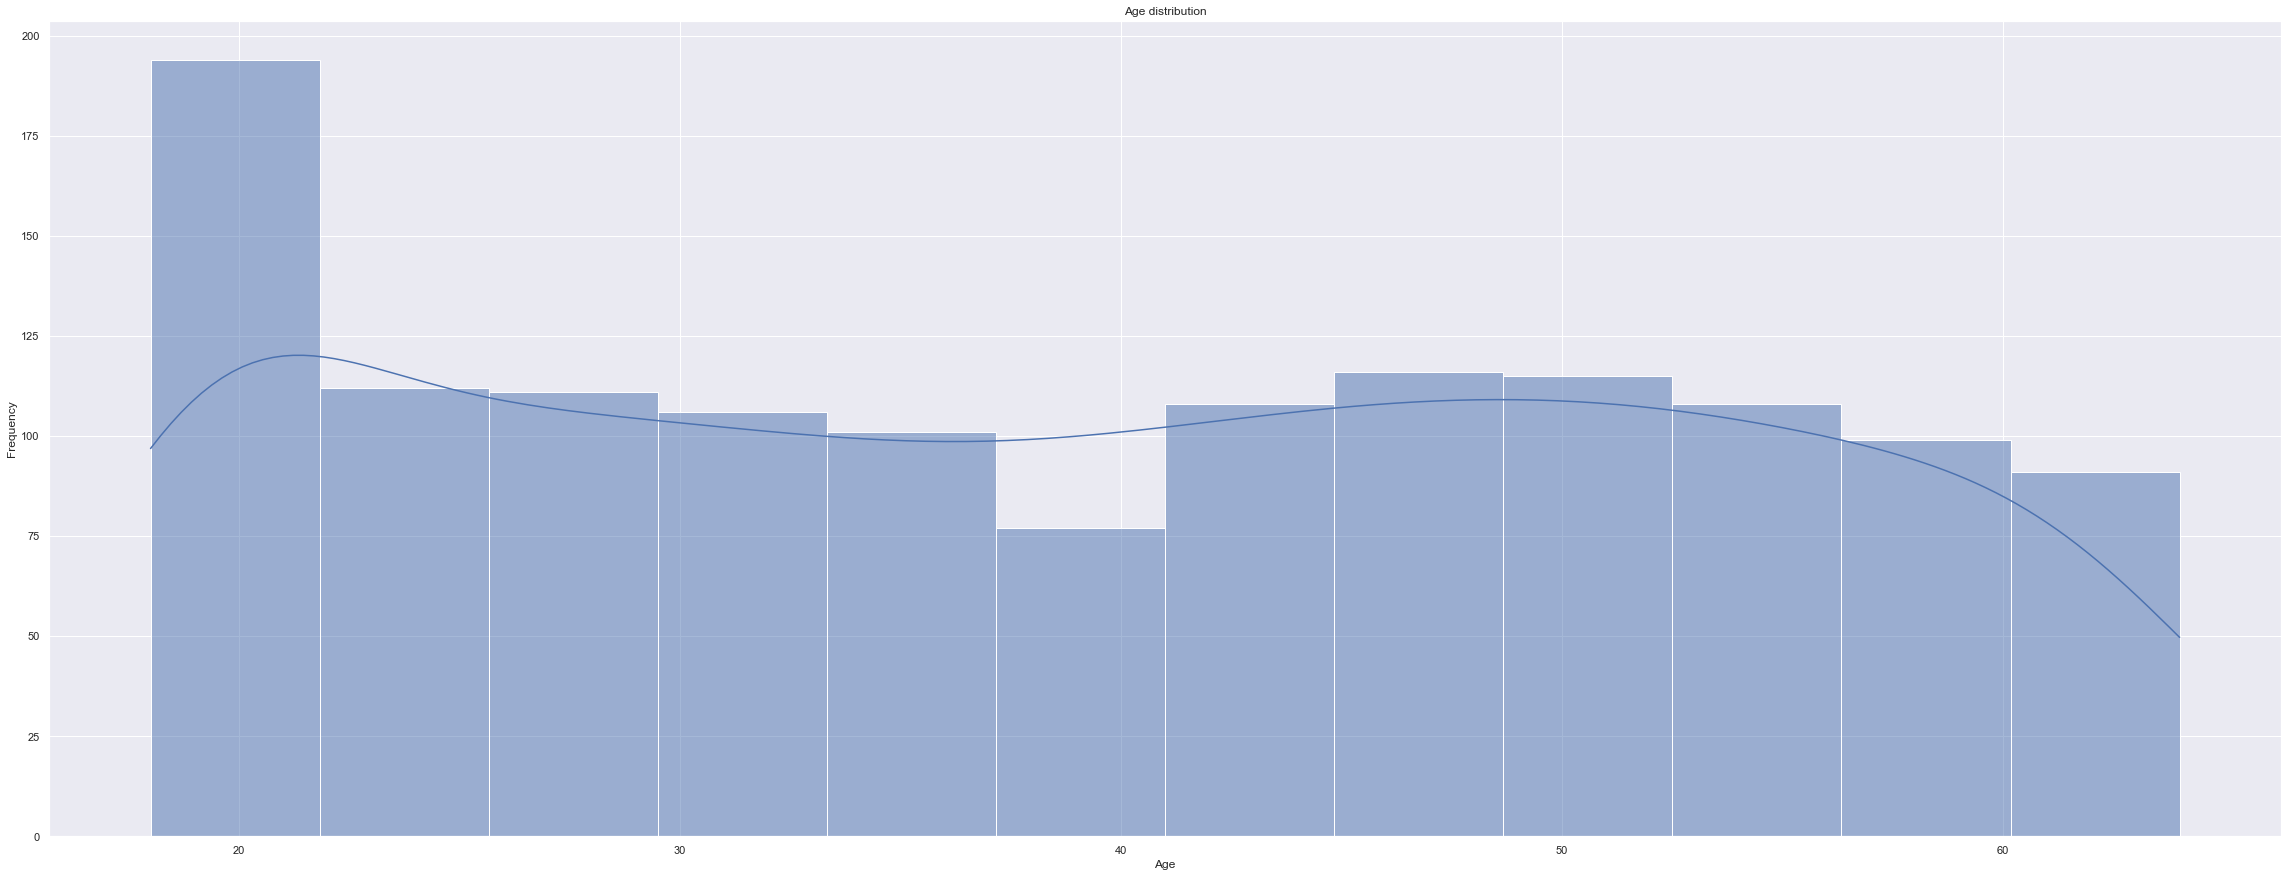

In [618]:
# plot the probabilyt age distribution 
sns.histplot(df["age"],kde=True)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()



The correlation plot - bmi vs age indicated that bmi has no correlction with age and scattered equally over all ages.

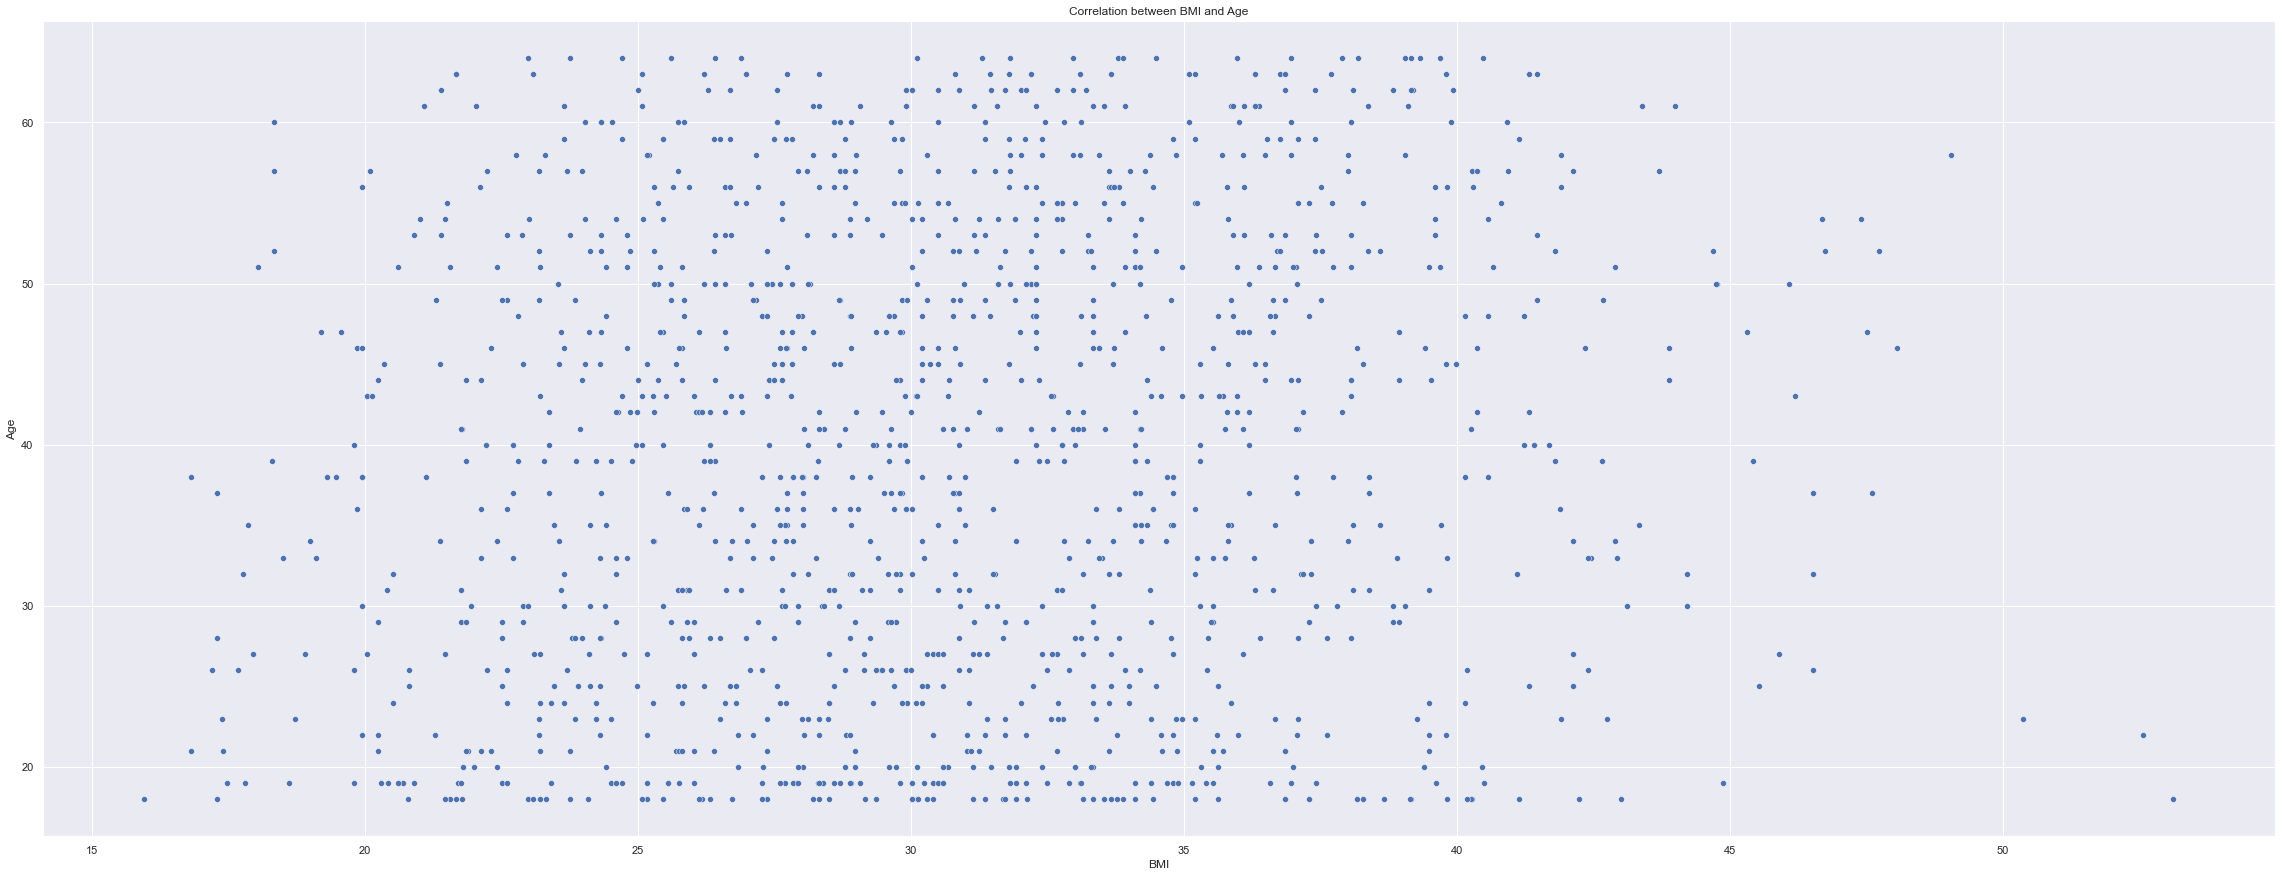

In [619]:

# age vs BMI scatter plot to show the correlation between age and BMI
sns.scatterplot(x="bmi", y="age", data=df)
plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("Correlation between BMI and Age")
plt.show()

BMI

The correlation plot between bmi and charges showed that as bmi increase (obess and overweigt) the members medical charges also increased though it's not a strong.

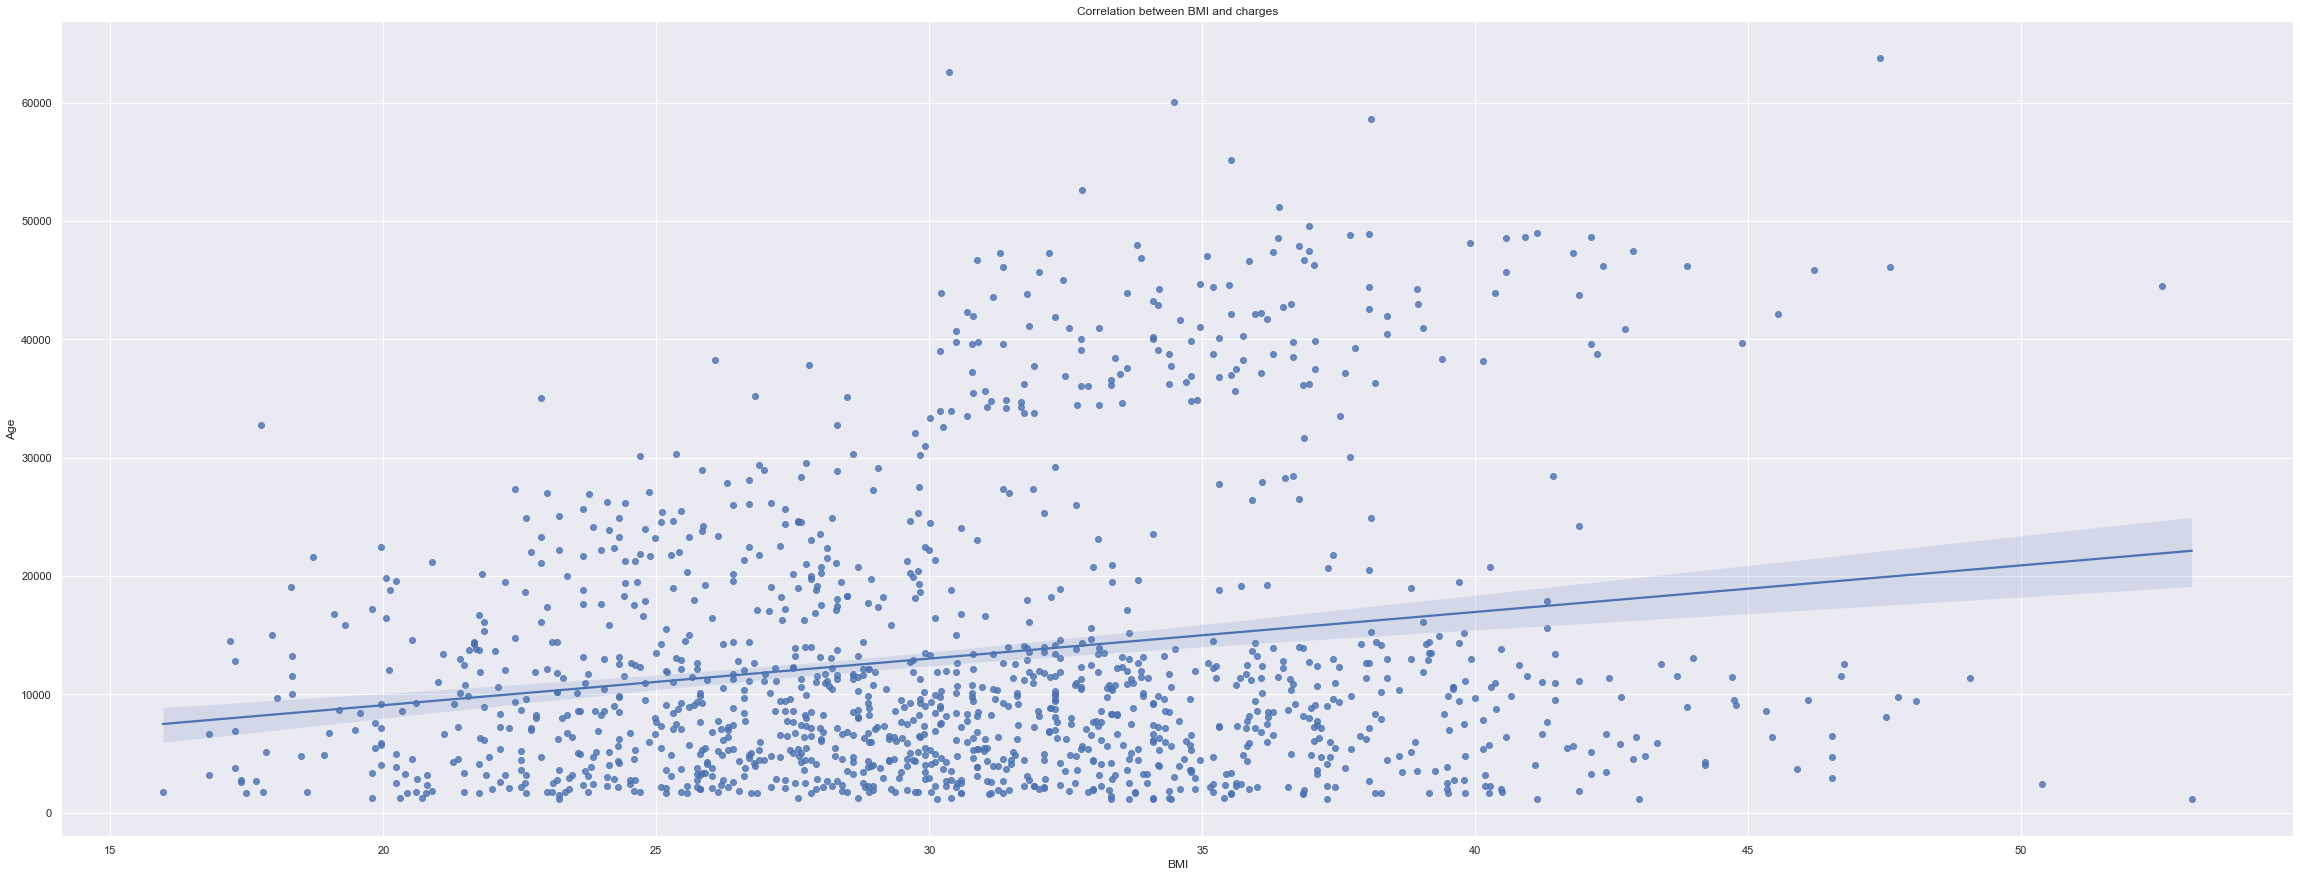

In [620]:
# BMI vs Charge

sns.regplot(x="bmi", y="charges", data=df)
plt.xlabel("BMI")
plt.ylabel("Age")
plt.title("Correlation between BMI and charges")
plt.show()

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


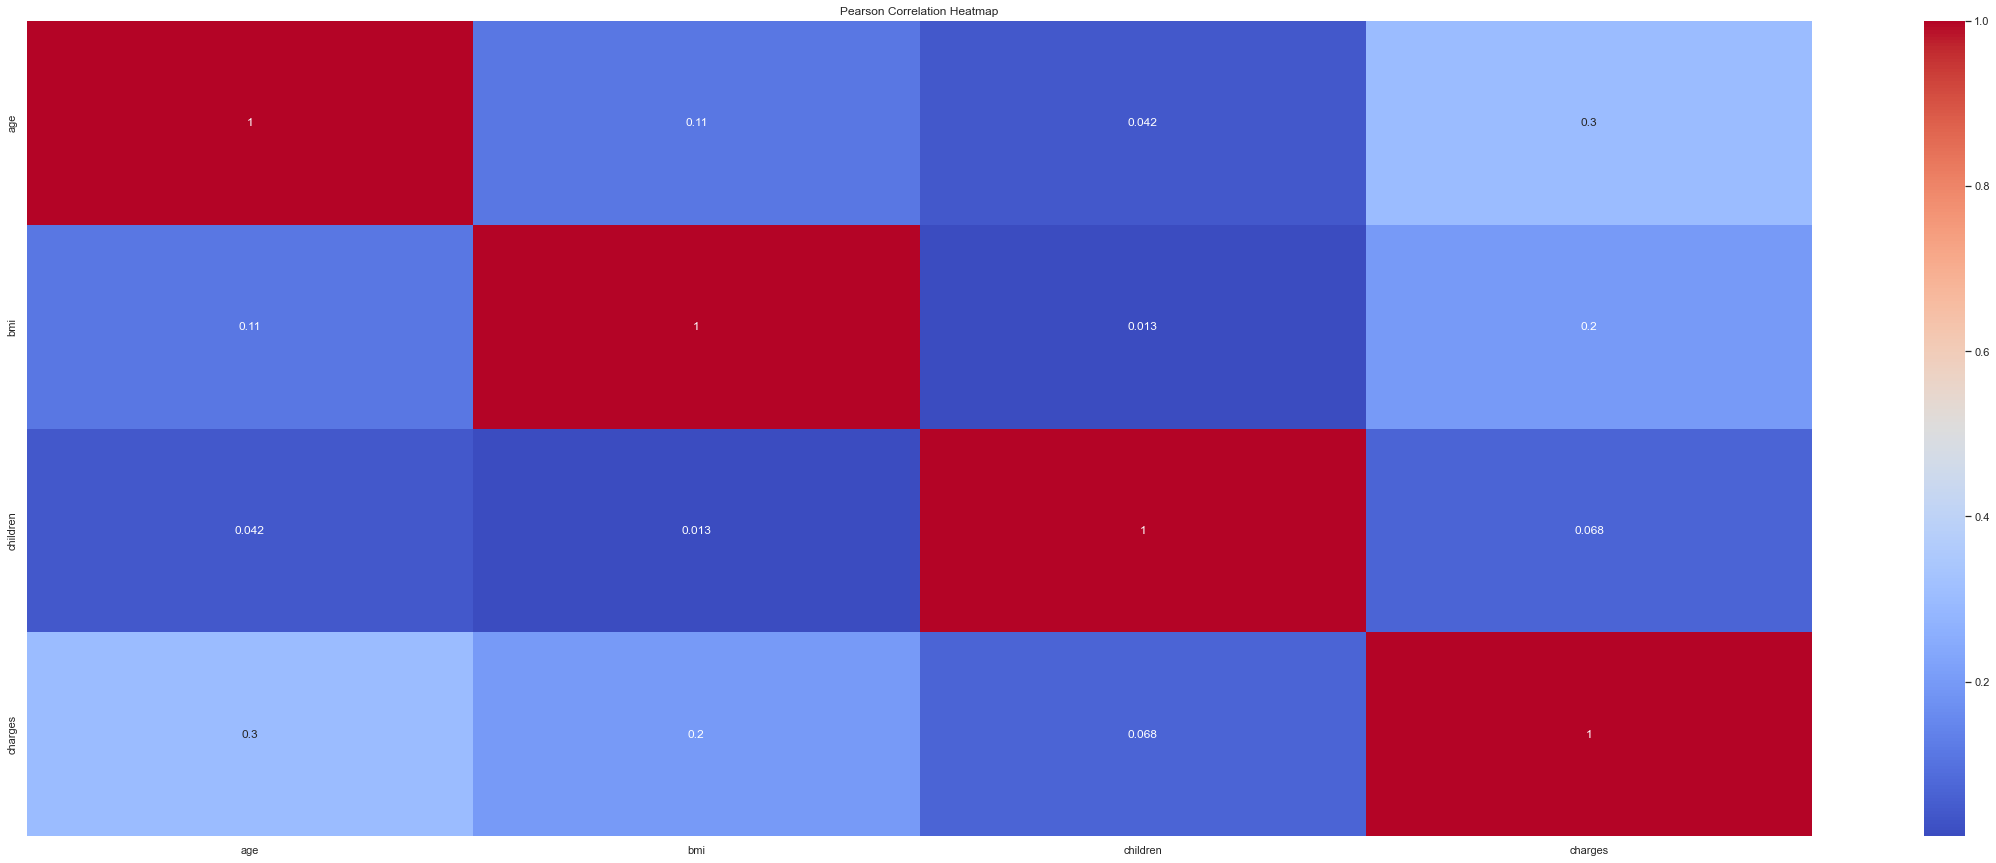

In [621]:
pearson_corr = df.corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

Correlation between bmi and charges: 0.19834096883362884


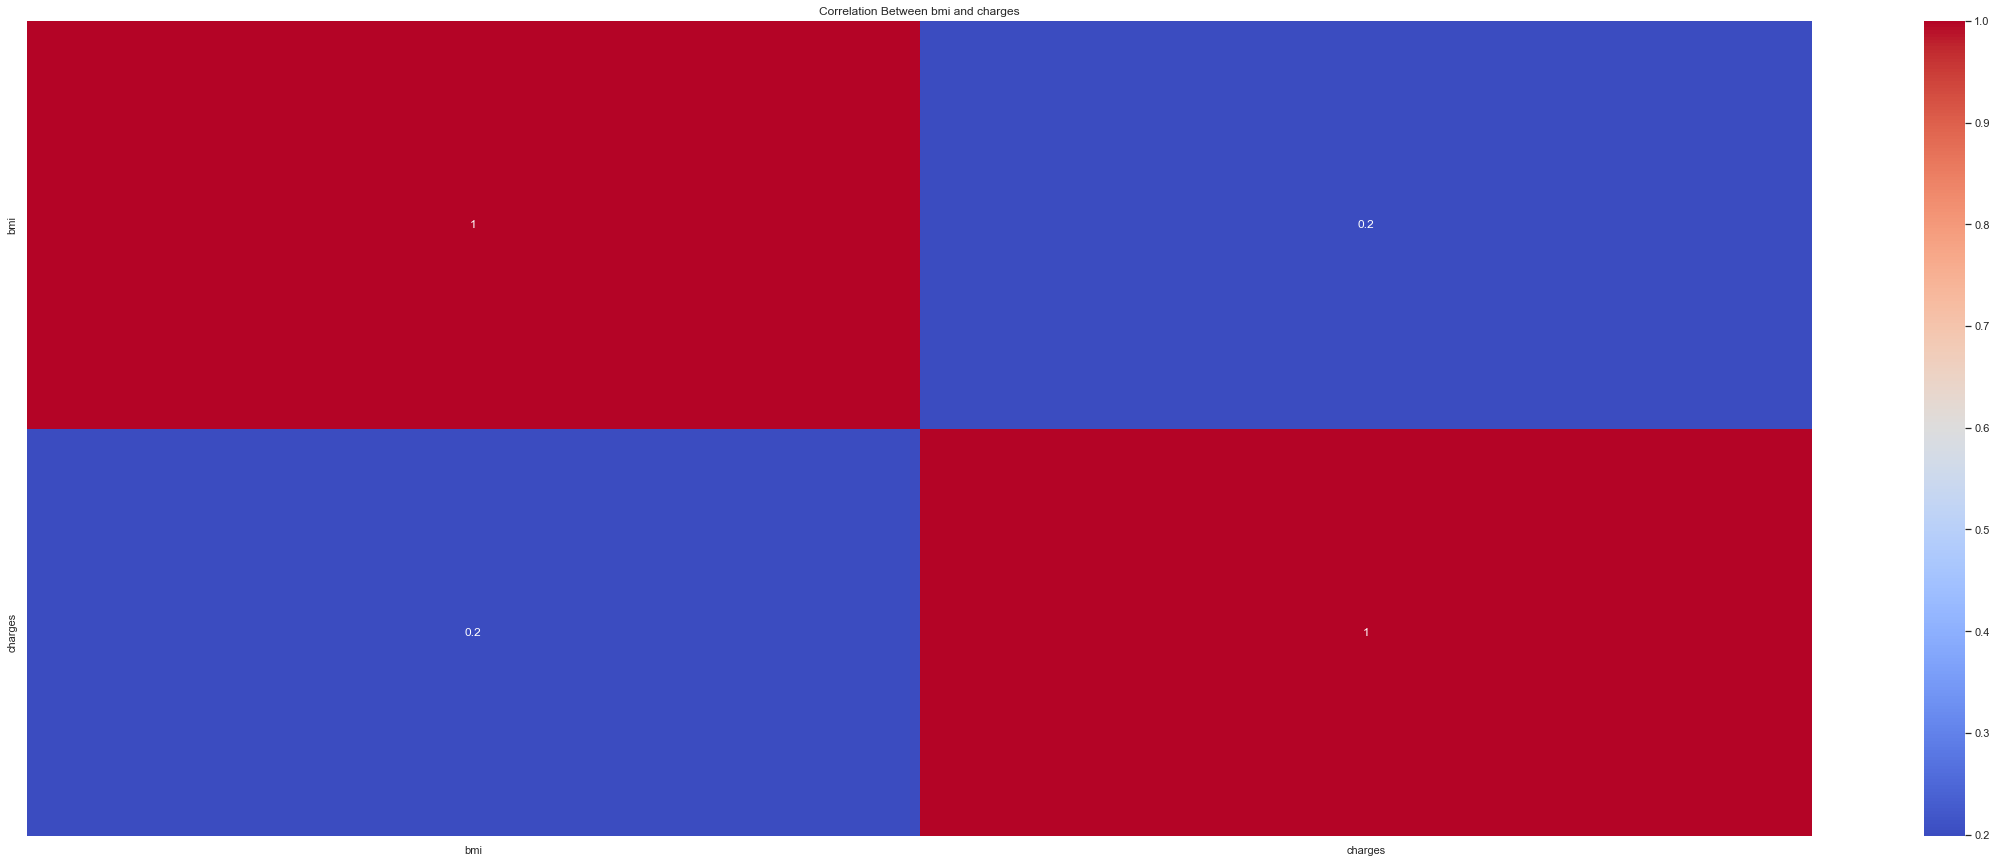

In [622]:
corr_value = df['bmi'].corr(df['charges'])
print("Correlation between bmi and charges:", corr_value)

two_col_corr = df[['bmi', 'charges']].corr()

sns.heatmap(two_col_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between bmi and charges")
plt.show()

In [596]:
# Group BMI into categories and count the number of records in each category
df['bmi_group'] = pd.cut(df['bmi'],
bins=[0, 18.5, 24.9, 29.9, np.inf],
labels=['Underweight', 'Normal weight', 'Overweight',
'Obesity'])
print(df.groupby('bmi_group').size())
# Describe summary of charge by bmi group
print(df.groupby("bmi_group")["charges"].describe())


bmi_group
Underweight       21
Normal weight    221
Overweight       380
Obesity          716
dtype: int64
               count          mean           std        min         25%  \
bmi_group                                                                 
Underweight     21.0   8657.620652   7591.730101  1621.3402  2775.19215   
Normal weight  221.0  10404.900084   7508.165722  1121.8739  4032.24070   
Overweight     380.0  11006.809989   8004.176052  1252.4070  4731.70725   
Obesity        716.0  15491.542238  14508.128111  1131.5066  5134.73970   

                       50%           75%          max  
bmi_group                                              
Underweight    6640.544850  12829.455100  32734.18630  
Normal weight  8604.483650  15359.104500  35069.37452  
Overweight     8659.378000  15595.840620  38245.59327  
Obesity        9895.213925  19870.751212  63770.42801  


In [597]:
# profile by smoking status
print(df.groupby("smoker").size())

smoker
no     1064
yes     274
dtype: int64


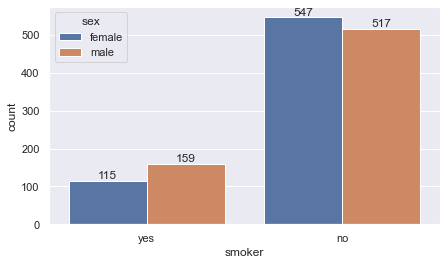

In [599]:
# insurance smoker distribution based on sex(Male and Female). I used smd variable for smoker distribution
sns.set(rc={'figure.figsize':(7,4)}) #adjust the x-axes width and height respectively
smd = sns.countplot(data = df, x = 'smoker', hue = 'sex')
for bars in smd.containers:
    smd.bar_label(bars)

#### Insured profile

Sex, smoking status, age and BMI

The average medical cost was $13,270, with a range of $11,210.87 and $63,770.43.



In [601]:
#describe() method returns describtion of the data in the DataFrame (i.e count, mean, std,max,  etc)
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [602]:
# sex distribution


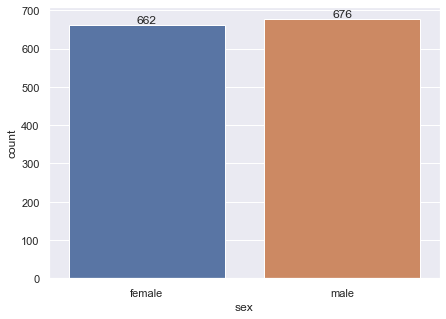

In [603]:
# number of insurance users by sex(Male and Female)
sns.set(rc={'figure.figsize':(7,5)}) #adjust the x-axes width and height respectively
mf = sns.countplot(x = 'sex', data = df)
for bars in mf.containers:
    mf.bar_label(bars)

The above graph shows that the number of insured persone based on thier sex(Male=676 and Female 662). It showes the number of male insurance users are more that females.

<AxesSubplot:xlabel='age', ylabel='count'>

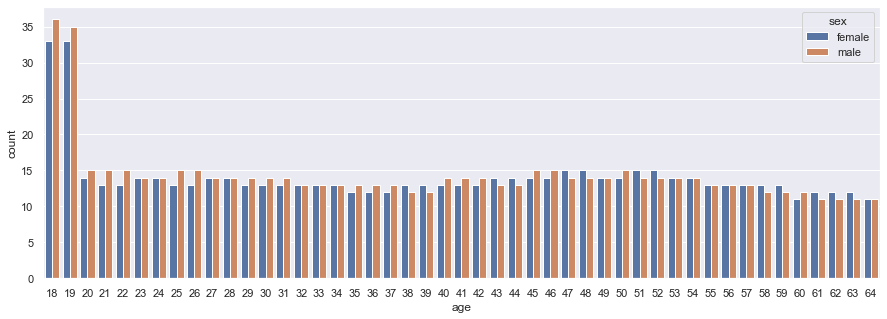

In [604]:
# insurance user graph male and female
sns.set(rc={'figure.figsize':(15,5)}) #adjust the x-axes width and height respectively
sns.countplot(data = df, x = 'age', hue = 'sex')

The above graph shows that the number of insurance users male and female based on their ages 

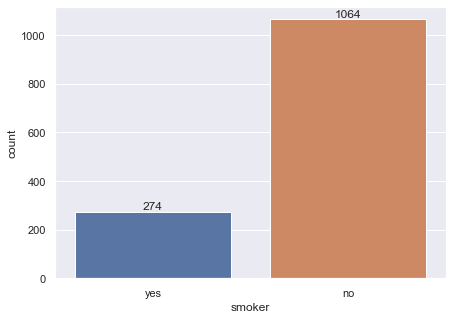

In [605]:
# insurance smoker distribution based on sex(Male and Female). I used sm variable for smoker distribution
sns.set(rc={'figure.figsize':(7,5)}) #adjust the x-axes width and height respectively
sm = sns.countplot(data = df, x = 'smoker')
for bars in sm.containers:
    sm.bar_label(bars)

From the above graph result shows that there are 274 smokers and 1064 no-smokers

From the above graph result shows that there are 115 female and 159 male smokers whereas 547 female and 517 male no-smokers 

From the above graph age 18 and 19 are the most number of insurance users 

The above graph shows that number of insurance users by region distribution

The graph Number of insurance users group by region and sex distribution of ascending order by charges

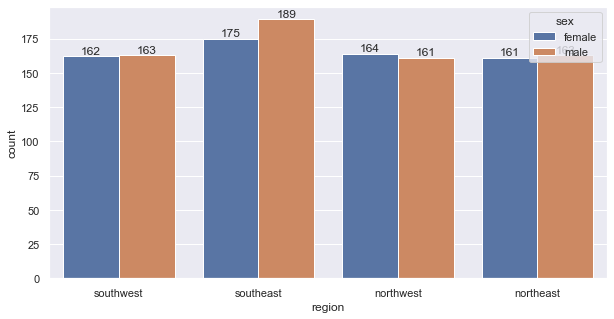

In [609]:
# number of insurance users by region and sex distribution
sns.set(rc={'figure.figsize':(10,5)}) #adjust the x-axes width and height respectively
rg = sns.countplot(x = 'region', data = df, hue= 'sex')
for bars in rg.containers:
    rg.bar_label(bars)